### Customer Churn Prediction — Simple Guide

**What is Churn?** A customer "churns" when they stop buying from a store. Our goal is to **predict** which customers are likely to stop coming back, using their past purchase history.

**What will we do?**
1. Load and clean the data
2. Create simple features (Recency, Frequency, Monetary = RFM)
3. Label each customer as "Churned" or "Retained"
4. Train two ML models: Logistic Regression and Random Forest
5. Compare how well each model predicts churn

---

## Step 1: Import Libraries
These are the tools we'll use throughout the notebook.

In [11]:
import pandas as pd                  # for working with tables of data
import numpy as np                   # for math
import matplotlib.pyplot as plt      # for plotting graphs
import seaborn as sns                # for prettier plots

from sklearn.model_selection import train_test_split   # split data into train/test
from sklearn.linear_model import LogisticRegression    # first ML model
from sklearn.ensemble import RandomForestClassifier    # second ML model
from sklearn.preprocessing import StandardScaler       # normalize features
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Make plots look nicer
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


---
## Step 2: Load & Clean the Data
We load the Online Retail dataset. Each row is a product bought in a transaction.

In [12]:
# Load the dataset
import os
path = os.path.join('..', '..', 'Datasets', 'online_retail.csv')
if not os.path.exists(path):
    path = os.path.join('Datasets', 'online_retail.csv')
df = pd.read_csv(path, encoding='latin1')

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Parse the date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

# Remove cancelled orders (they start with 'C') and rows with missing CustomerID
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df.dropna(subset=['CustomerID'])

# Remove rows where Quantity or UnitPrice is 0 or negative
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Add a Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f'Data loaded: {len(df):,} rows, {df["CustomerID"].nunique():,} unique customers')
print(f'Date range: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
df.head()

Data loaded: 397,884 rows, 4,338 unique customers
Date range: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
## Step 3: Create a Churn Label

We split the data into two time windows:
- **Feature window**: everything before the cutoff date → used to compute customer behaviour
- **Label window**: the 90 days after the cutoff → did the customer come back?

If a customer did **NOT** return in the label window, we mark them as **Churned (1)**.

In [13]:
# Set the cutoff date (leaves a 90-day observation window at the end)
cutoff = pd.Timestamp('2011-09-09')
label_end = cutoff + pd.Timedelta(days=90)

print(f'Feature window : start → {cutoff.date()}')
print(f'Label window   : {cutoff.date()} → {label_end.date()}')

# Split into before and after cutoff
before = df[df['InvoiceDate'] < cutoff]
after  = df[(df['InvoiceDate'] >= cutoff) & (df['InvoiceDate'] < label_end)]

# Customers who bought something AFTER the cutoff = retained
returned = set(after['CustomerID'].unique())

print(f'\nCustomers who had activity before cutoff: {before["CustomerID"].nunique():,}')
print(f'Of those, came back after cutoff: {len(returned):,}')

Feature window : start → 2011-09-09
Label window   : 2011-09-09 → 2011-12-08

Customers who had activity before cutoff: 3,362
Of those, came back after cutoff: 2,877


---
## Step 4: Build RFM Features

For each customer we compute 3 classic features:
- **Recency** — how many days since their last purchase (lower = more recent)
- **Frequency** — how many unique orders they made
- **Monetary** — total amount spent

In [14]:
# Group by customer and compute RFM
rfm = before.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (cutoff - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

# Add the churn label: 1 = churned, 0 = retained
rfm['Churned'] = (~rfm['CustomerID'].isin(returned)).astype(int)

print('Churn rate:')
print(rfm['Churned'].value_counts(normalize=True).rename({0:'Retained', 1:'Churned'}).round(3))
rfm.head()

Churn rate:
Churned
Retained    0.567
Churned     0.433
Name: proportion, dtype: float64


,CustomerID,Recency,Frequency,Monetary,Churned
0,12346.0,233,1,77183.60,1
1,12347.0,37,5,2790.86,0
2,12348.0,156,3,1487.24,0
3,12350.0,218,1,334.40,1
4,12352.0,170,5,1561.81,0


---
## Step 5: Visualise the Data
Let's see how Recency, Frequency, and Monetary differ between churned and retained customers.

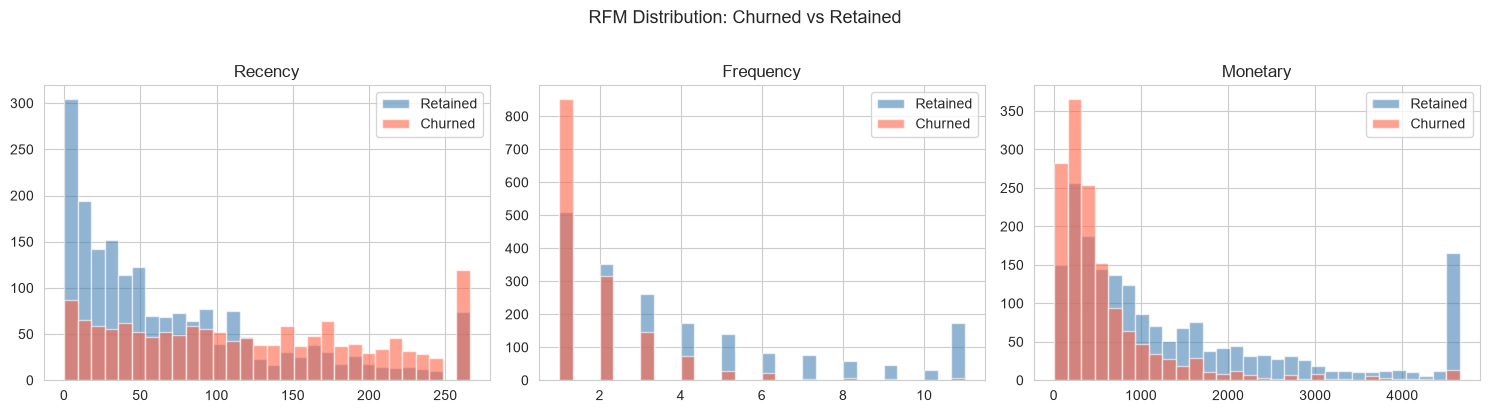

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    rfm[rfm['Churned']==0][col].clip(upper=rfm[col].quantile(0.95)).hist(
        ax=ax, alpha=0.6, label='Retained', color='steelblue', bins=30)
    rfm[rfm['Churned']==1][col].clip(upper=rfm[col].quantile(0.95)).hist(
        ax=ax, alpha=0.6, label='Churned', color='tomato', bins=30)
    ax.set_title(col)
    ax.legend()

plt.suptitle('RFM Distribution: Churned vs Retained', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6: Prepare Data for Machine Learning
We split the data into training (75%) and testing (25%) sets, then scale the features.

In [16]:
# Define features (X) and target label (y)
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]
y = rfm['Churned']

# Split: 75% train, 25% test — stratify keeps same churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features so they're all on the same scale (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]} customers')
print(f'Testing set  : {X_test.shape[0]} customers')

Training set : 2521 customers
Testing set  : 841 customers


---
## Step 7: Train Model 1 — Logistic Regression
A simple, fast model that works like a probability calculator. It answers: "What is the probability this customer will churn?"

In [17]:
# Train the model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr   = lr.predict(X_test_scaled)
y_proba_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression Results ===')
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.3f}')
print('\nROC-AUC: 0.5 = random guessing, 1.0 = perfect. Higher is better!')

=== Logistic Regression Results ===
              precision    recall  f1-score   support

    Retained       0.71      0.68      0.70       477
     Churned       0.60      0.64      0.62       364

    accuracy                           0.66       841
   macro avg       0.66      0.66      0.66       841
weighted avg       0.66      0.66      0.66       841

ROC-AUC Score: 0.719

ROC-AUC: 0.5 = random guessing, 1.0 = perfect. Higher is better!


---
## Step 8: Train Model 2 — Random Forest
A more powerful model that builds many decision trees and combines their predictions. Usually more accurate than Logistic Regression.

In [18]:
# Train the model (100 trees, balanced to handle any class imbalance)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)   # Random Forest doesn't need scaling

# Make predictions
y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest Results ===')
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.3f}')

=== Random Forest Results ===
              precision    recall  f1-score   support

    Retained       0.70      0.65      0.68       477
     Churned       0.58      0.63      0.61       364

    accuracy                           0.65       841
   macro avg       0.64      0.64      0.64       841
weighted avg       0.65      0.65      0.65       841

ROC-AUC Score: 0.691


---
## Step 9: Confusion Matrices
A confusion matrix shows us how many customers the model got right vs wrong.

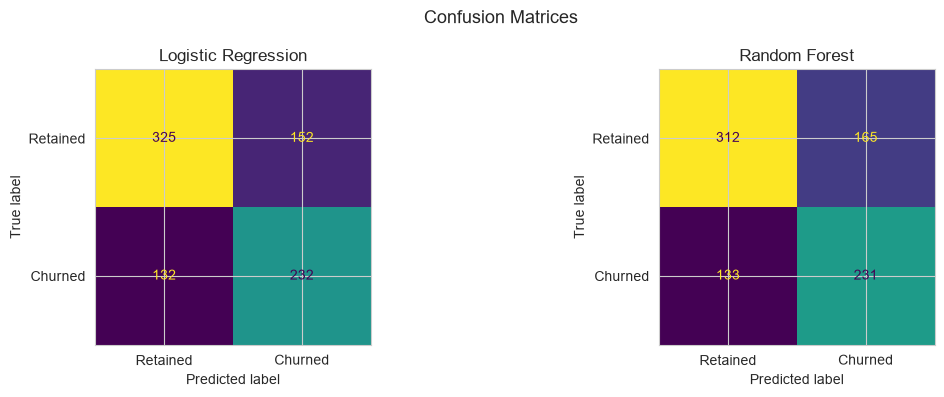


Top-left & bottom-right = correct predictions (the more the better!)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [y_pred_lr, y_pred_rf],
                             ['Logistic Regression', 'Random Forest']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['Retained', 'Churned'],
        colorbar=False, ax=ax
    )
    ax.set_title(title)

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()
print('\nTop-left & bottom-right = correct predictions (the more the better!)')

---
## Step 10: Feature Importance (Random Forest)
Which feature (Recency, Frequency, Monetary) matters most for predicting churn?

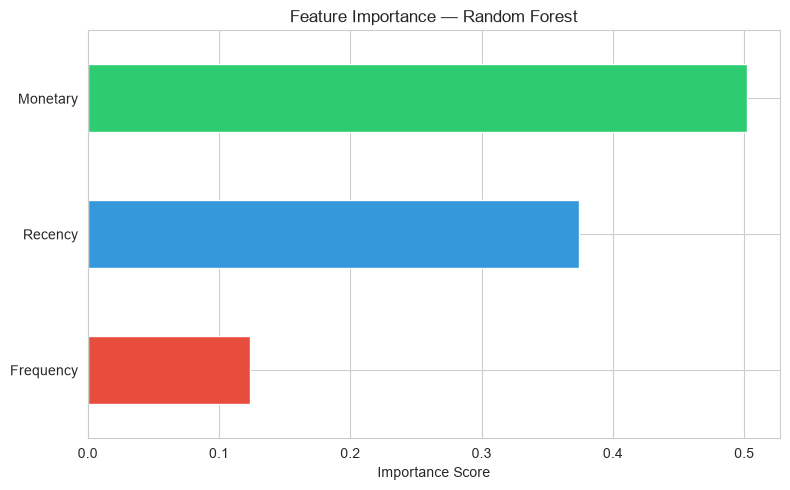


The longer the bar, the more that feature helps predict churn.


In [20]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

importances.plot(kind='barh', color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nThe longer the bar, the more that feature helps predict churn.')

---
##  Summary

| Model | What it does | Needs Scaling? |
|---|---|---|
| Logistic Regression | Estimates churn probability using a formula | Yes |
| Random Forest | Combines many decision trees for better accuracy | No |

**Key Metrics to look at:**
- **Precision** — of customers predicted as churned, how many actually churned?
- **Recall** — of customers that actually churned, how many did we catch?
- **ROC-AUC** — overall model quality (closer to 1.0 = better)
